# IPL EDA + Feature Engineering

In [9]:

import cv2, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import skew
from tqdm import tqdm
from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "images"
LABEL_CSV = DATA_DIR / "master.csv"
OUTPUT_CSV = DATA_DIR / "features.csv"
CHUNK_SIZE = 5000


In [10]:

df = pd.read_csv(LABEL_CSV)
cell_cols = [f'c{i:02d}' for i in range(1,65)]
print(df.shape)
df.head()


(3659, 68)


,image,labelled_by,num_players,submitted_by,c01,c02,c03,c04,c05,c06,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,GTvsLSG_image_0.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,GTvsLSG_image_1.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GTvsLSG_image_10.jpg,Vishal,2.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GTvsLSG_image_11.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GTvsLSG_image_12.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,0,0


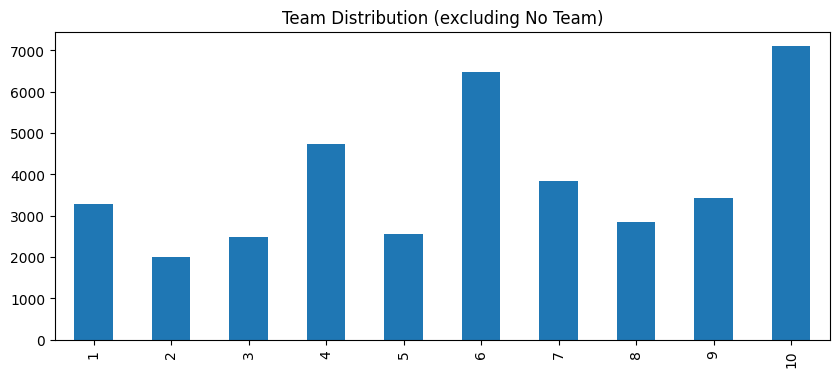

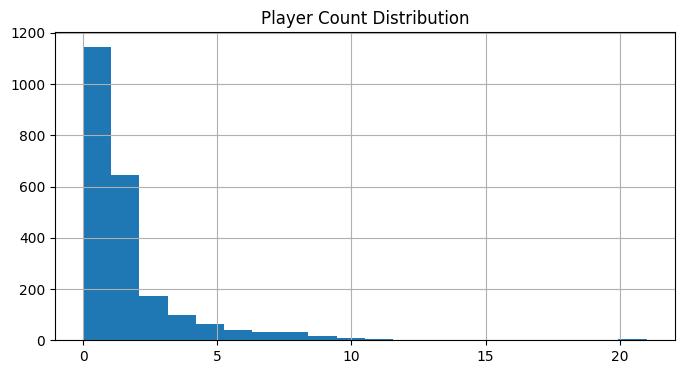

In [11]:

# EDA
all_labels = df[cell_cols].values.flatten()
dist = pd.Series(all_labels).value_counts().sort_index()
team_dist = dist[dist.index != 0]

plt.figure(figsize=(10,4))
team_dist.plot(kind='bar')
plt.title("Team Distribution (excluding No Team)")
plt.show()

plt.figure(figsize=(8,4))
df['num_players'].hist(bins=20)
plt.title("Player Count Distribution")
plt.show()


In [13]:

def split_into_cells(image):
    return [image[r*75:(r+1)*75, c*100:(c+1)*100] for r in range(8) for c in range(8)]

def rgb_hist(cell):
    feats=[]
    for ch in range(3):
        h=cv2.calcHist([cell],[ch],None,[16],[0,256])
        feats.extend(cv2.normalize(h,h).flatten())
    return np.array(feats)

def hsv_hist(cell):
    hsv=cv2.cvtColor(cell,cv2.COLOR_RGB2HSV)
    feats=[]
    for ch in range(3):
        h=cv2.calcHist([hsv],[ch],None,[16],[0,256])
        feats.extend(cv2.normalize(h,h).flatten())
    return np.array(feats)

def color_moments(cell):
    out=[]
    for ch in cv2.split(cell):
        out += [np.mean(ch), np.std(ch), skew(ch.flatten())]
    return np.array(out)

def lbp_feat(cell):
    gray=cv2.cvtColor(cell,cv2.COLOR_RGB2GRAY)
    lbp=local_binary_pattern(gray,8,1,method='uniform')
    hist,_=np.histogram(lbp.ravel(),bins=np.arange(0,11),range=(0,10))
    return hist/(hist.sum()+1e-6)

def glcm_feat(cell):
    gray=cv2.cvtColor(cell,cv2.COLOR_RGB2GRAY)
    g=graycomatrix(gray,[1],[0],256,symmetric=True,normed=True)
    return np.array([graycoprops(g,p)[0,0] for p in ['contrast','homogeneity','energy','correlation']])

def canny_feat(cell):
    gray=cv2.cvtColor(cell,cv2.COLOR_RGB2GRAY)
    e=cv2.Canny(gray,100,200)
    density=(e>0).sum()/e.size
    hist,_=np.histogram(e,bins=16,range=(0,256))
    hist=hist/(hist.sum()+1e-6)
    return np.concatenate([[density],hist])

def hog_feat(cell):
    gray=cv2.cvtColor(cell,cv2.COLOR_RGB2GRAY)
    return hog(gray,orientations=9,pixels_per_cell=(16,16),cells_per_block=(2,2),visualize=False)

def extract_features(cell):
    return np.concatenate([
        rgb_hist(cell), hsv_hist(cell), color_moments(cell),
        lbp_feat(cell), glcm_feat(cell), canny_feat(cell), hog_feat(cell)
    ])


In [14]:

# Build features.csv (chunked)
header_written=False
buffer=[]

for _,row in tqdm(df.iterrows(), total=len(df)):
    p = IMAGE_DIR / row['image']
    if not p.exists():
        continue

    img=cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

    for idx,cell in enumerate(split_into_cells(img)):
        feat=extract_features(cell)

        rec={
            'image_name':row['image'],
            'cell_id':idx+1,
            'label':row[cell_cols[idx]]
        }

        for i,v in enumerate(feat):
            rec[f'f_{i+1}']=v

        buffer.append(rec)

    if len(buffer)>=CHUNK_SIZE:
        pd.DataFrame(buffer).to_csv(
            OUTPUT_CSV,
            mode='a',
            index=False,
            header=not header_written
        )
        header_written=True
        buffer=[]

if buffer:
    pd.DataFrame(buffer).to_csv(
        OUTPUT_CSV,
        mode='a',
        index=False,
        header=not header_written
    )

print("Saved:", OUTPUT_CSV)


  1%|          | 24/3659 [00:03<09:52,  6.13it/s]/var/folders/1m/r53kmn99675gj6mlypwb9w9r0000gn/T/ipykernel_5133/3288648728.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  out += [np.mean(ch), np.std(ch), skew(ch.flatten())]
  4%|▎         | 137/3659 [00:24<09:29,  6.19it/s]/var/folders/1m/r53kmn99675gj6mlypwb9w9r0000gn/T/ipykernel_5133/3288648728.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  out += [np.mean(ch), np.std(ch), skew(ch.flatten())]
 14%|█▍        | 524/3659 [01:38<08:46,  5.95it/s]/var/folders/1m/r53kmn99675gj6mlypwb9w9r0000gn/T/ipykernel_5133/3288648728.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results m

Saved: ../data/features.csv
